# Imports

In [200]:
from ModifiedNEAT.nn.base import NeatModule
from load_data import MnistDataloader
from ModifiedNEAT.util.storage import STORAGE_DIR
from ModifiedNEAT.util.qol import manage_params
from ModifiedNEAT.util.datetime import clock, eta
from ModifiedNEAT.util.storage import save, load
from ModifiedNEAT.util.fancy_text import CM, Fore

import ModifiedNEAT as meat
import ModifiedNEAT.nn as mnn
import ModifiedNEAT.optim as optim
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math
import random
import warnings

from torch import Tensor
from torch.optim import Optimizer
from torch.nn.utils import clip_grad_norm_
from torchvision import transforms
from numpy import ndarray as CPUArray
from typing import Union
from copy import deepcopy
from matplotlib.pyplot import Axes
from numba.core.errors import NumbaPerformanceWarning

In [201]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DTYPE = torch.bfloat16
GENOMES = 20
meat.util.storage.set_storage_location("../../storage")

In [202]:
warnings.filterwarnings("ignore", category=NumbaPerformanceWarning)

# Load Data

In [203]:
ABS_PATH = './mnist_data/'
loader = MnistDataloader(
    f"{ABS_PATH}train-images.idx3-ubyte",
    f"{ABS_PATH}train-labels.idx1-ubyte",
    f"{ABS_PATH}t10k-images.idx3-ubyte",
    f"{ABS_PATH}t10k-labels.idx1-ubyte",
)
RESIZE = (16, 16)
(train_inp, train_out), (eval_inp, eval_out) = loader.load_data(
    GENOMES, 1000, 21000, resize=RESIZE, rand_rot=False, rand_flip=False, batch_size=128,
    normalize=True,
    device='cpu', dtype=DTYPE
)
train_inp.shape, train_out.shape, eval_inp.shape, eval_out.shape

Loaded 1000 records.
Loaded 10000 records.


(torch.Size([20, 1000, 1, 16, 16]),
 torch.Size([20, 1000]),
 torch.Size([20, 10000, 1, 16, 16]),
 torch.Size([20, 10000]))

In [204]:
def tensor_memory(tensor: Tensor):
    """

    :param tensor: PyTorch tensor
    :return: Memory in Megabytes
    """
    return tensor.numel() * tensor.element_size() / (1024 ** 2)

In [205]:
tensor_memory(eval_inp)

97.65625

In [206]:
[(torch.max(t).cpu(), torch.min(t).cpu()) for t in [train_inp, eval_inp]]

[(tensor(1., dtype=torch.bfloat16), tensor(0., dtype=torch.bfloat16)),
 (tensor(1., dtype=torch.bfloat16), tensor(0., dtype=torch.bfloat16))]

In [207]:
train_inp.device, train_inp.dtype, train_inp.device, train_out.dtype

(device(type='cpu'), torch.bfloat16, device(type='cpu'), torch.int64)

In [208]:
torch.max(train_inp)

tensor(1., dtype=torch.bfloat16)

In [209]:
IMG_SHAPE = train_inp.shape[3:]
IMG_SHAPE

torch.Size([16, 16])

# View data

In [210]:
def show_image(image: Tensor, title: str = None, size: tuple[int, int] = None, cmap='binary', axis: Axes = None):
    if size is None:
        size = (360, 360)
    if image.ndim == 3:
        image = image.permute(1, 2, 0)
    elif image == 2:
        pass
    else:
        raise ValueError(f"Unsupported ndim")
    image = image.cpu().float()
    if axis is None:
        _, axis = plt.subplots(1, 1, figsize=(size[0] * 0.01, size[1] * 0.01))
    axis.imshow(image, cmap=cmap)
    if title is not None:
        axis.set_title(title)
    axis.set_axis_off()
    if axis is None:
        plt.show()

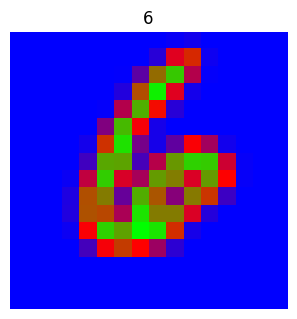

In [211]:
rand_train_idx = np.random.randint(0, len(train_inp))
show_image(train_inp[0, rand_train_idx], train_out[0, rand_train_idx].item(), cmap='brg')

In [212]:
def show_batch(images: Tensor, predictions: Tensor = None, labels: Tensor = None, columns=8,
               size: tuple[int, int] = None, cmap='binary', no_axes=True):
    if size is None:
        size = (720, 1080)
    if images.ndim == 4:
        images = images.permute(0, 2, 3, 1)
    elif images == 3:
        pass
    else:
        raise ValueError(f"Unsupported ndim")

    images = images.cpu().float()
    rows = math.ceil(len(images) / columns)
    fig, axes = plt.subplots(rows, columns, figsize=(size[1] * 0.01, size[0] * 0.01))
    if isinstance(axes, CPUArray):
        axes = axes.flatten()
    else:
        axes = [axes]

    for index, (axis, image) in enumerate(zip(axes, images)):
        axis.imshow(image, cmap=cmap)
        title = ''
        if predictions is not None:
            title += f"P={predictions[index].cpu().item()}"
        if labels is not None:
            title += f"L={labels[index].cpu().item()}"
        if len(title) > 0:
            axis.set_title(title)
        if no_axes:
            axis.set_axis_off()
    plt.show()

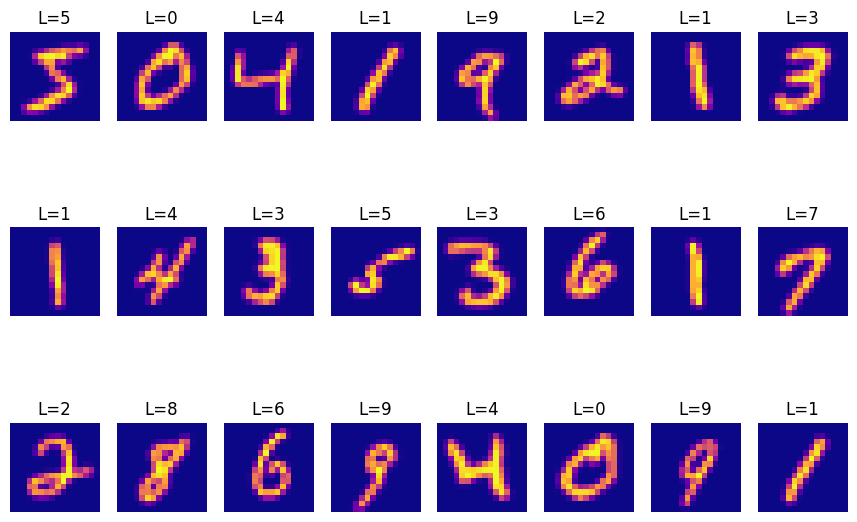

In [213]:
show_batch(train_inp[0, :24], labels=train_out[0, :24], cmap='plasma')

# Model Architecture

In [214]:
from typing import Iterable

class Average(nn.Module):
    def __init__(self, dims=None, keepdims=False):
        super(Average, self).__init__()
        self.dims = dims
        self.keepdims = keepdims

    def forward(self, input: Tensor) -> Tensor:
        return torch.mean(input, dim=self.dims, keepdim=self.keepdims)

class Permute(nn.Module):
    def __init__(self, dims: int | Iterable[int]):
        super(Permute, self).__init__()
        if not isinstance(dims, Iterable):
            dims = [dims]
        self.dims = tuple(dims)

    def forward(self, input: Tensor) -> Tensor:
        extra = tuple(range(max(0, input.ndim-len(self.dims))))
        return input.permute(extra+self.dims)

    def extra_repr(self):
        return f"dims={self.dims}"

class SimpleCNN(meat.NeatModule):
    def __init__(self, inputs: int, outputs: int, dim_size: int, layers: int, kernel_size: int, img_size: tuple[int, int],
                 fc_size: int, div=1, actv=nn.SiLU(), bias=False, device='cpu', dtype=torch.float32):
        super().__init__()
        sequence = nn.ModuleList()
        padding = 0
        for layer_idx in range(layers+1):
            # size_ = tuple([dim - (kernel_size-1) * layer_idx for dim in img_size])
            if layer_idx < layers:
                # if layer_idx == 0:
                    sequence.append(mnn.Conv2d(
                        inputs if layer_idx == 0 else dim_size+(dim_size//div*(layer_idx-1)),
                        outputs if layer_idx == layers else dim_size+(dim_size//div*layer_idx),
                        kernel_size=kernel_size, bias=bias, device=device, dtype=dtype,
                        padding=padding, padding_mode='zeros'
                    ))
                # else:
                #    sequence.append(mnn.ResidualBlock(
                #         inputs if layer_idx == 0 else dim_size+(dim_size//div*(layer_idx-1)),
                #         outputs if layer_idx == layers else dim_size+(dim_size//div*layer_idx),
                #         kernel_size=kernel_size, bias=bias, device=device, dtype=dtype,
                #         padding=padding, padding_mode='zeros', image_ndim=2, norm_groups=1,
                #    ))
                # if layer_idx == layers-1:
                    sequence.append(
                        mnn.GroupNorm(1, dim_size+(dim_size//div*layer_idx) if layer_idx != layers else outputs,
                                      bias=bias, device=device, dtype=dtype)
                    )
                    sequence.append(actv)
            else:
                # fc_inputs = (dim_size+(dim_size//div*(layers-1))) * math.prod(img_size)
                ndim = len(img_size) + 1 # Convolution dimensions + Feature dimension
                permutation = list(range(-ndim+1, 0)) + [-ndim]
                sequence.extend([
                    Permute(permutation),
                    nn.Flatten(-(len(img_size)+1), -1),
                    nn.AdaptiveAvgPool1d(fc_size),
                    mnn.Linear(fc_size, outputs, bias=bias, device=device, dtype=dtype)
                ])
        self.sequence = mnn.Sequential(*sequence)
        # self.mean_std = mnn.Linear(fc_size, outputs * 2, bias=bias, device=device, dtype=dtype)
        # self.mean = mnn.Linear(fc_size, outputs, bias=bias, device=device, dtype=dtype)

        # Attributes
        self.inputs     = inputs
        self.outputs    = outputs
        self.dim_size   = dim_size
        self.kernel_size = kernel_size
        self.layers     = layers
        self.div        = div
        self.bias       = bias
        self.fc_size    = fc_size

        # States
        self.device     = device
        self.dtype      = dtype

    def forward(self, tensor: Tensor, keys: Union[int, list[int]] = None, verbose: int = None):
        tensor = (tensor - 0.5) * 2.0
        tensor = self.sequence(tensor, keys=keys)
        # mean, log_std = torch.chunk(self.mean_std(tensor, keys=keys), 2, -1)
        # std = torch.exp(torch.tanh(log_std) * 6)
        # dist = torch.distributions.Normal(mean, std)
        # tensor = dist.sample()
        # tensor = self.mean(tensor, keys=keys)
        # tensor = F.log_softmax(tensor, dim=-1)
        return tensor

    def evaluate(self, tensor: Tensor, keys: Union[int, list[int]] = None):
        return torch.argmax(self.forward(tensor, keys), dim=-1)

DyParam = Union[int, list[int]]

class EnsembleCNN(meat.NeatModule):
    def __init__(self, inputs: int, outputs: int, kernel_sizes: DyParam, dim_sizes: DyParam, layers: DyParam,
                 img_size: tuple[int, int], fc_size: int, divs: DyParam, actv=nn.SiLU(),
                 bias=False, device='cpu', dtype=torch.float32):
        super(EnsembleCNN, self).__init__()
        if isinstance(kernel_sizes, (int, float)):
            kernel_sizes = [kernel_sizes]

        self.networks: list[SimpleCNN] = nn.ModuleList()
        for k_idx, kernel_size in enumerate(kernel_sizes):
            dim_size    = dim_sizes if isinstance(dim_sizes, (int, float)) else dim_sizes[min(k_idx, len(dim_sizes)-1)]
            layer_num   = layers if isinstance(layers, (int, float)) else layers[min(k_idx, len(layers)-1)]
            div         = divs if isinstance(divs, (int, float)) else divs[min(k_idx, len(divs)-1)]
            self.networks.append(SimpleCNN(
                inputs, outputs, dim_size, layer_num, kernel_size, img_size, fc_size, div, actv, bias, device, dtype
            ))

        # Attributes
        self.inputs     = inputs
        self.outputs    = outputs
        self.img_size   = img_size
        self.bias       = bias

        # States
        self.device     = device
        self.dtype      = dtype

    def forward(self, tensor: Tensor, keys: Union[int, list[int]] = None, verbose: int = None):
        summation = []
        for module in self.networks:
            summation.append(module(tensor, keys=keys))
        return torch.sum(torch.stack(summation), dim=0)

    def evaluate(self, tensor: Tensor, keys: Union[int, list[int]] = None, verbose: int = None):
        return torch.argmax(self.forward(tensor, keys=keys, verbose=verbose), dim=-1)

    def guess(self, tensor, keys: Union[int, list[int]] = None):
        logits = self.forward(tensor, keys=keys)
        dist = torch.distributions.Categorical(F.softmax(logits, -1))
        return dist.sample()

    def save(self, file_no: int = None):
        g_params = f"globals-i{self.inputs}-o{self.outputs}-b{self.bias}-s{self.img_size[0]}_{self.img_size[1]}"
        for network in self.networks:
            name = f"params_{g_params}_locals-d{network.dim_size}-" \
                     f"k{network.kernel_size}-l{network.layers}-d{network.div}"
            params = network.state_dict()
            save(params, name, 'mnist_models', subdirectory=f"{network.__class__.__name__}", file_no=file_no)

    def load(self, file_no: int = None):
        g_params = f"globals-i{self.inputs}-o{self.outputs}-b{self.bias}-s{self.img_size[0]}_{self.img_size[1]}"
        for network in self.networks:
            name = f"params_{g_params}_locals-d{network.dim_size}-" \
                     f"k{network.kernel_size}-l{network.layers}-d{network.div}"
            params = load(name, 'mnist_models', subdirectory=f"{network.__class__.__name__}", file_no=file_no)
            if params is not None:
                network.load_state_dict(params)

In [215]:
test_inputs = torch.randn(1, 3, 1, *IMG_SHAPE, dtype=DTYPE)
# CHANNELS = (
#     [32 + 16 * max(0, 4*n-1) for n in range(3)],
# )
_KERNELS = (3, 5, 7)
_DIMENSIONS = (32, 48, 64)
CHANNELS_LAYERS = (3, 2, 1)
test_model = EnsembleCNN(
    inputs=1, outputs=10, kernel_sizes=_KERNELS, dim_sizes=_DIMENSIONS,
    layers=CHANNELS_LAYERS, fc_size=512,
    img_size=IMG_SHAPE, divs=2, actv=nn.SiLU(),
    bias=True, device='cpu', dtype=DTYPE
)
print(test_model)
with torch.no_grad():
    test_outputs = test_model.evaluate(test_inputs, verbose=2)
    # test_model.save()
    # test_model.load()
test_outputs, test_outputs.shape

EnsembleCNN(
  (networks): ModuleList(
    (0): SimpleCNN(
      (sequence): Sequential[NeatModule](
        (0): Conv2d[NeatModule](channels_in=1, channels_out=32, kernel_size=(3, 3), stride=1, padding=(0, 0), dilation=1, groups=1, bias=True, padding_mode=zeros)
        (1): GroupNorm[NeatModule](groups=1, channels=32, eps=1e-09, affine=True, bias=True)
        (2): SiLU()
        (3): Conv2d[NeatModule](channels_in=32, channels_out=48, kernel_size=(3, 3), stride=1, padding=(0, 0), dilation=1, groups=1, bias=True, padding_mode=zeros)
        (4): GroupNorm[NeatModule](groups=1, channels=48, eps=1e-09, affine=True, bias=True)
        (5): SiLU()
        (6): Conv2d[NeatModule](channels_in=48, channels_out=64, kernel_size=(3, 3), stride=1, padding=(0, 0), dilation=1, groups=1, bias=True, padding_mode=zeros)
        (7): GroupNorm[NeatModule](groups=1, channels=64, eps=1e-09, affine=True, bias=True)
        (8): SiLU()
        (9): Permute(dims=(-2, -1, -3))
        (10): Flatten(start_d

(tensor([[6, 6, 6]]), torch.Size([1, 3]))

# Create Model

In [216]:
def model_size(model: meat.NeatModule):
    return np.sum([param.numel() * param.element_size() for param in model.parameters()]) / (1024 ** 2)

In [217]:
def model_params(model: meat.NeatModule):
    return np.sum([param.numel() for param in model.parameters()])

In [218]:
INPUT_DIMS = 1
OUTPUT_DIMS = 10
DIM_SIZE = 8
# DEPTH = 3
LAYERS = 3
BIAS = False

In [219]:
MODEL = EnsembleCNN(
    inputs=INPUT_DIMS, outputs=OUTPUT_DIMS, kernel_sizes=(3,),
    dim_sizes=(DIM_SIZE,), layers=(LAYERS,), img_size=IMG_SHAPE, fc_size=2048, divs=2,
    bias=BIAS, device=DEVICE, dtype=DTYPE, actv=nn.SiLU()
)
MODEL

EnsembleCNN(
  (networks): ModuleList(
    (0): SimpleCNN(
      (sequence): Sequential[NeatModule](
        (0): Conv2d[NeatModule](channels_in=1, channels_out=8, kernel_size=(3, 3), stride=1, padding=(0, 0), dilation=1, groups=1, bias=False, padding_mode=zeros)
        (1): GroupNorm[NeatModule](groups=1, channels=8, eps=1e-09, affine=True, bias=False)
        (2): SiLU()
        (3): Conv2d[NeatModule](channels_in=8, channels_out=12, kernel_size=(3, 3), stride=1, padding=(0, 0), dilation=1, groups=1, bias=False, padding_mode=zeros)
        (4): GroupNorm[NeatModule](groups=1, channels=12, eps=1e-09, affine=True, bias=False)
        (5): SiLU()
        (6): Conv2d[NeatModule](channels_in=12, channels_out=16, kernel_size=(3, 3), stride=1, padding=(0, 0), dilation=1, groups=1, bias=False, padding_mode=zeros)
        (7): GroupNorm[NeatModule](groups=1, channels=16, eps=1e-09, affine=True, bias=False)
        (8): SiLU()
        (9): Permute(dims=(-2, -1, -3))
        (10): Flatten(star

# Create Population

In [220]:
CONFIG = meat.Config('mnist')

In [221]:
MULTIPLIER = 0.1
CONFIG.genome.init_type             = 'normal'
CONFIG.genome.weight_init_mean      = 0.0
CONFIG.genome.weight_init_std       = 0.3142
CONFIG.genome.weight_min_value      = -np.inf
CONFIG.genome.weight_max_value      = +np.inf
CONFIG.genome.weight_mutate_power   = 1e-1
CONFIG.genome.weight_mutate_rate    = 0.60
CONFIG.genome.weight_replace_rate   = 0.00
CONFIG.genome.weight_add_prob       = 0.00
CONFIG.genome.weight_del_prob       = 0.00
CONFIG.genome.param_epsilon         = 1e-9
CONFIG.genome.single_structural_mutation = False
CONFIG.reproduction.min_species_size = GENOMES
CONFIG.reproduction.purge           = 1
CONFIG.reproduction.survival_threshold = 0.20
CONFIG.reproduction.darwin_multiplier = 0.50
CONFIG.reproduction.elitism         = 10
CONFIG.species.compatibility_threshold = np.inf
CONFIG.stagnation.max_stagnation    = 1
CONFIG.stagnation.species_elitism   = 1
CONFIG.save()
CONFIG.load(2)

Created configuration 'GENERAL CONFIG' in NEAT Configuration mnist-neat_config.txt
Created configuration 'GENOME CONFIG' in NEAT Configuration mnist-neat_config.txt
Created configuration 'SPECIES CONFIG' in NEAT Configuration mnist-neat_config.txt
Created configuration 'STAGNATION CONFIG' in NEAT Configuration mnist-neat_config.txt
Created configuration 'REPRODUCTION CONFIG' in NEAT Configuration mnist-neat_config.txt
fitness_criterion         = max
fitness_threshold         = inf
pop_size                  = 100
reset_on_extinction       = True
seed                      = 237976
Loaded configuration 'GENERAL CONFIG' in NEAT Configuration mnist-neat_config.txt
weight_init_mean          = 0.0
weight_init_std           = 0.3142
weight_max_value          = inf
weight_min_value          = -inf
weight_mutate_power       = 0.1
weight_mutate_rate        = 0.6
weight_replace_rate       = 0.0
weight_add_prob           = 0.0
weight_del_prob           = 0.0
param_epsilon             = 1e-09
compat

In [222]:
POPULATION = meat.Population(GENOMES, MODEL, CONFIG, init_reporter=True)

Initialized genomes in  in 0.41s
Ran distance kernel in 0.02 s
Created distances cache in 0.3 s
Collected species representatives in 0.0 s
Filled species in 0.0 s
Updated species mapping in 0.0 s
Completed speciating in 0.3 s
Mean genetic distance 0.237, standard deviation 0.056, with 1 species


In [223]:
# POPULATION.load_dict(name="mnist", file_no=None, verbose=True)

In [224]:
def faulty_genome(key: int):
        return any(torch.any(p.data[p.mapping[key]] == 0) for p in MODEL.neat_parameters())
[k for k in POPULATION.genomes.keys() if faulty_genome(k)]

[]

In [225]:
test_key = POPULATION.best_genome.key if POPULATION.best_genome is not None else list(POPULATION.genomes.keys())[0]
test_index = MODEL.mapping[test_key]
# for param in MODEL.parameters():
#     full_zero_param = torch.all(param[test_index] == 0).cpu().item()
#     if full_zero_param:
#         print(f"Found zero parameter: {param.shape}")
# for module in MODEL.modules():
#     if not isinstance(module, NeatModule):
#         print(f"Found non-NEAT parameter: {module.__class__.__name__}")
test_key, test_index, MODEL

(110,
 0,
 EnsembleCNN(
   (networks): ModuleList(
     (0): SimpleCNN(
       (sequence): Sequential[NeatModule](
         (0): Conv2d[NeatModule](channels_in=1, channels_out=8, kernel_size=(3, 3), stride=1, padding=(0, 0), dilation=1, groups=1, bias=False, padding_mode=zeros)
         (1): GroupNorm[NeatModule](groups=1, channels=8, eps=1e-09, affine=True, bias=False)
         (2): SiLU()
         (3): Conv2d[NeatModule](channels_in=8, channels_out=12, kernel_size=(3, 3), stride=1, padding=(0, 0), dilation=1, groups=1, bias=False, padding_mode=zeros)
         (4): GroupNorm[NeatModule](groups=1, channels=12, eps=1e-09, affine=True, bias=False)
         (5): SiLU()
         (6): Conv2d[NeatModule](channels_in=12, channels_out=16, kernel_size=(3, 3), stride=1, padding=(0, 0), dilation=1, groups=1, bias=False, padding_mode=zeros)
         (7): GroupNorm[NeatModule](groups=1, channels=16, eps=1e-09, affine=True, bias=False)
         (8): SiLU()
         (9): Permute(dims=(-2, -1, -3))
  

In [226]:
f"{model_size(MODEL):.3f}", f"{model_params(MODEL):.2e}"

('0.884', '4.64e+05')

In [227]:
SCHEDULERS = [
    # optim.scheduler.CosineAnnealing(CONFIG, 50, 1e-2, 'weight_mutate_power', True, True),
    # optim.scheduler.RandomAnnealing(CONFIG, 1e-3, 1e-1, 'weight_mutate_power', True),
    optim.scheduler.CosineAnnealing(CONFIG, 20, 0.05, 'weight_mutate_rate', True, True),
    # optim.scheduler.RandomAnnealing(CONFIG, 0.00, 0.70, 'weight_mutate_rate', False),
    # optim.scheduler.CosineAnnealing(CONFIG, 100, 0.01, 'weight_replace_rate', True, True),
]

In [228]:
SCHEDULERS[0].step()
f"{CONFIG.genome.weight_mutate_power:.4e}"

'1.0000e-01'

In [229]:
# POPULATION.load_dict(name="mnist", file_no=None, verbose=True)

# Train

In [230]:
def cross_entropy_loss(logits: Tensor, targets: Tensor):
    """
    Gets the cross entropy loss for genomes, given logits and targets.
    :param logits: Assumes last dimension is for logit probabilities.
    :param targets: Assumes last dimension is for target values.
    :return:
    """
    assert logits.ndim >= 2
    assert logits.ndim -1 == targets.ndim
    genome_num, classes_num = logits.shape[0], logits.shape[-1]
    return F.cross_entropy(
        logits.view(genome_num, -1, classes_num).mT,
        targets.view(genome_num, -1),
        reduction="none"
    ).mean(dim=-1)

In [231]:
test_classes    = 10
test_genomes    = 3
test_batches    = 32
test_seq_len    = 4
test_device     = 'cpu' if torch.cuda.is_available() else 'cpu'
test_tensor_logt = torch.normal(0, 3.14e-1, (test_genomes, test_batches, test_seq_len, test_classes)).to(test_device)
test_tensor_targ = torch.randint(0, test_classes, (test_genomes, test_batches, test_seq_len)).to(test_device)
test_losses = cross_entropy_loss(test_tensor_logt, test_tensor_targ)
test_losses_normal = F.cross_entropy(test_tensor_logt.permute(0, -1, 1, 2), test_tensor_targ, reduction='none').mean(-1)
test_tensor_logt[:2, :2, :3,], test_losses_normal[:5].mean(-1), test_losses.shape, test_losses[:5]

(tensor([[[[-0.2955, -0.0339, -0.2636, -0.0214, -0.3357,  0.0745,  0.2018,
            -0.0290, -0.3413,  0.2696],
           [ 0.3160,  0.7585, -0.2186,  0.1714,  0.4514,  0.4022, -0.2109,
             0.1442, -0.0569,  0.1699],
           [-0.1820,  0.2237, -0.0977,  0.2832, -0.1121, -0.2872,  0.1262,
             0.1790,  0.0028,  0.3021]],
 
          [[-0.2835, -0.2077, -0.1363, -0.1059,  0.1821,  0.1353, -0.0986,
            -0.2734, -0.0711,  0.0489],
           [ 0.0419, -0.2567, -0.1184,  0.2676, -0.1720,  0.0908, -0.2230,
             0.0760, -0.2083,  0.0953],
           [-0.1629,  0.6582, -0.1077, -0.2664,  0.3100,  0.4521, -0.1392,
            -0.3131, -0.1524,  0.0425]]],
 
 
         [[[ 0.1776, -0.3622, -0.3597,  0.3014, -0.3294,  0.2484,  0.0291,
            -0.5311,  0.4770, -0.3343],
           [ 0.2980, -0.1899, -0.1279,  0.0567, -0.3252, -0.2264,  0.0296,
             0.2609, -0.2296, -0.2330],
           [-0.2314, -0.0729, -0.6331,  0.2030, -0.2946, -0.0424,  0.03

In [232]:
%%timeit -n 10 -r 3
_test_val = torch.stack([
    F.cross_entropy(log.view(-1, test_classes), targ.view(-1).to(torch.long)) for log, targ in zip(test_tensor_logt, test_tensor_targ)
])[:5]

275 μs ± 13.5 μs per loop (mean ± std. dev. of 3 runs, 10 loops each)


In [233]:
%%timeit -n 10 -r 3
_test_val = cross_entropy_loss(test_tensor_logt, test_tensor_targ)

115 μs ± 26.5 μs per loop (mean ± std. dev. of 3 runs, 10 loops each)


In [234]:
MODEL(eval_inp[:len(POPULATION.genomes), :10].to(DEVICE, DTYPE), verbose=2).shape

torch.Size([20, 10, 10])

In [235]:
def get_batches(records: int, batch_size: int = None, shuffle=False):
    if batch_size is None:
        batch_size = records
    assert records > 0
    if batch_size is None:
        batch_size = records
    else:
        assert batch_size > 0
        batch_size = min(batch_size, records)

    indices: list[int] = list(range(records))
    if shuffle:
        random.shuffle(indices)
    batch_indices: list[list[int]] = list()
    batch: list[int] = list()
    for i, index in enumerate(indices):
        batch.append(index)
        batch_is_filled = len(batch) == batch_size
        no_more_records = i == len(indices) - 1 and not batch_is_filled
        if batch_is_filled or no_more_records:
            batch_indices.append(batch)
            batch = list()

    return batch_indices

In [236]:
BATCH_SIZE = 64

In [237]:
def get_accuracy(model: meat.NeatModule, inputs, outputs, batch_size: int, guess=False, verbose=False,
                 keys: Union[int, list[int]] = None, mean=False):
    if keys is not None and not isinstance(keys, (tuple, list)):
        keys = [keys]
    if keys is not None:
        mapping = POPULATION.get_mapping()
        key_indices = [mapping[key] for key in keys]
        inputs, outputs = inputs[key_indices], outputs[key_indices]

    torch.cuda.empty_cache()
    batch_indices = get_batches(inputs.shape[1], batch_size, True)
    summation = {index: 0 for index in range(len(outputs))}
    elements = {index: 0 for index in range(len(outputs))}
    # print(inputs.shape, outputs.shape, len(batch_indices), max([len(batch) for batch in batch_indices]))
    ts = clock.perf_counter()
    for step, batch in enumerate(batch_indices):
        with torch.no_grad():
            images = inputs[:, batch].to(model.device)
            target: Tensor = outputs[:, batch].to(model.device)
            if not guess:
                prediction: torch.Tensor = model.evaluate(images, keys=keys)
            else:
                prediction: torch.Tensor = model.guess(images, keys=keys)
            total = prediction == target
            for index, (sub_total, sub_target) in enumerate(zip(total, target)):
                summation[index] += sub_total.sum().item()
                elements[index] += sub_target.numel()
        if verbose:
            eta(ts, step+1, len(batch_indices), f"Getting accuracy")
    if verbose:
        print(f"\nCalculated accuracy in {clock.perf_counter()-ts:.2f}s")

    accuracy = {index: s / e for (index, s), e in zip(summation.items(), elements.values())}
    torch.cuda.empty_cache()
    if not mean:
        return np.max(list(accuracy.values())).item()
    else:
        return np.mean(list(accuracy.values())).item()
MODEL.eval();

In [238]:
get_accuracy(MODEL, eval_inp, eval_out, BATCH_SIZE, verbose=True, keys=list(POPULATION.genomes.keys()))

Getting accuracy: progress=100% eta=0sec
Calculated accuracy in 24.41s


0.166

In [239]:
(1-get_accuracy(MODEL, train_inp, train_out, BATCH_SIZE, keys=list(POPULATION.genomes.keys())))*100, \
(1-get_accuracy(MODEL, eval_inp, eval_out, BATCH_SIZE, keys=list(POPULATION.genomes.keys())))*100

(85.2, 83.39999999999999)

In [240]:
train_inp.shape

torch.Size([20, 1000, 1, 16, 16])

In [241]:
test_predictions = MODEL(train_inp[:1, :6].to(MODEL.device), keys=test_key, verbose=3)
test_predictions.cpu().float().numpy()

array([[[-0.37695312,  0.5234375 ,  3.5625    , -1.4453125 ,
         -0.68359375,  1.5       ,  0.10791016, -1.9609375 ,
          1.2734375 , -0.36328125],
        [-0.26171875, -1.5078125 ,  1.4609375 , -2.484375  ,
          1.3359375 , -0.27539062,  0.59765625, -0.09863281,
         -1.2734375 ,  0.24316406],
        [-3.140625  ,  1.2890625 ,  3.65625   , -5.375     ,
         -1.84375   , -1.6484375 , -0.47265625, -1.296875  ,
         -2.328125  ,  1.6953125 ],
        [-1.25      ,  2.640625  ,  3.96875   , -0.15722656,
         -1.7421875 ,  0.22460938,  0.00582886, -0.44335938,
          1.71875   ,  1.7890625 ],
        [ 0.07666016,  0.578125  ,  1.546875  , -2.375     ,
          0.734375  , -1.3515625 ,  0.8359375 , -1.078125  ,
         -0.3671875 ,  1.7890625 ],
        [-0.48828125, -0.40820312,  2.296875  , -1.1171875 ,
          1.6015625 , -1.8046875 , -1.6796875 , -1.8984375 ,
          0.20800781,  2.15625   ]]], dtype=float32)

In [242]:
from ModifiedNEAT.rl.base import Algorithm, ReplayBuffer

class Trainer(Algorithm):
    def __init__(self, eval_func, model, population, schedulers=None, device='cpu', dtype=torch.float32, **options):
        for var in ['schedulers', 'device', 'dtype']:
            if var in options:
                del options[var]
        super().__init__(population, schedulers, device, dtype, **options)
        self.model = model
        self.evaluate = eval_func

        self.primary.add_buffers('score', 'ep_map')

        # ---------- Options ----------
        self.alpha = manage_params(options, 'alpha', 1.0)

        # ---------- Logging ----------
        pass

    def updates_scores(self, losses: Tensor):
        self.handle_episode_mapping(False, force_reset=True)
        scores = -losses
        # scores = (scores - scores.mean()) / (scores.std() + 1e-8)
        # minimum, maximum = torch.min(scores), torch.max(scores)
        norm_scores = scores # (scores - minimum) / (maximum - minimum + 1e-12)
        # norm_scores = (norm_scores - 0.5) * 2
        self.primary.update(
            score=norm_scores,
            ep_map=self.episode_mapping[0]
        )

        self.steps_done += 1
        self.episodes_done = max(self.episode_mapping.values()) + 1
        self.prev_steps_done = self.steps_done

    def get_returns(self):
        scores, episode_mapping = self.primary.rollout(['score', 'ep_map'], as_list=True, stack=True)
        self.sort_episodes(episode_mapping, scores)
        cum_scores = self.compute_returns(scores, 0, self.alpha, True, episode_mapping)
        return cum_scores, episode_mapping

    def set_scores(self):
        scores, episode_mapping = self.primary.rollout(['score', 'ep_map'], as_list=True, stack=True)
        self.sort_episodes(episode_mapping, scores)
        cum_scores = self.compute_returns(scores, 0, self.alpha, True, episode_mapping)
        for key, score in cum_scores.items():
            self.population.genomes[key].fitness = torch.mean(score).cpu().item()

    def run(self, epochs: int, display=True, checkpoint=1):
        torch.cuda.empty_cache()
        losses: list[float] = []
        accuracies: list[float] = []
        genomes: list[int] = []
        mean = []
        std = []

        ts = clock.perf_counter()
        for scheduler in self.schedulers:
            scheduler.reset()
        best_score = None if self.population.best_genome is None else self.population.best_genome.fitness
        save_state = self.population.save_dict()[0]
        try:
            for epoch in range(epochs):
                # gs = list(self.population.genomes.keys())
                # print(f"Genomes: {gs[:5]}... {gs[-5:]}")
                self.population.run(
                    self.evaluate, 1, trainer=self,
                    losses=losses, accuracies=accuracies, genomes=genomes, mean=mean, std=std,
                    epoch=epoch, verbose=False if epoch==0 else False
                )
                for scheduler in self.schedulers:
                    scheduler.step()
                if epoch % checkpoint == 0 and (best_score is None or self.population.best_genome.fitness >= best_score):
                    best_score = self.population.best_genome.fitness
                    save_state = self.population.save_dict()[0]

                eta(ts, epoch+1, epochs, f"NEAT training: loss={losses[-1]:.4f} ({min(losses):.4f})")
        except KeyboardInterrupt as e:
            print(CM(e, Fore.LIGHTRED_EX))
        except Exception as e:
            raise e
        # except (RuntimeError, StopIteration, ValueError) as e:
        #     raise e
        self.population.load_dict(save_state, verbose=False)
        print(f"\nFinished NEAT training in {clock.perf_counter() - ts:.1f}s. Best genome: {self.population.best_genome.key}, Loss: {losses[-1]:.4f}")

        if display:
            plt.close()
            axes = plt.subplots(1, 3, figsize=(14.4, 5.4))[1]
            axes = axes.flatten()
            axes[0].plot(losses)
            axes[0].set_title('Loss')
            axes[1].plot(accuracies)
            axes[1].set_title('Accuracy')
            axes[2].plot(genomes)
            axes[2].set_title('Genome')

        torch.cuda.empty_cache()
        return losses

In [243]:
all([all([torch.all(t[i1] == t[i1]).cpu().item() for t in [train_inp, train_out, eval_inp, eval_out]]) for i0, i1 in [(i, i+1) for i in range(GENOMES-1)]])

True

In [244]:
import math
MAX_EPISODES = 3
ALPHA = math.exp(math.log(1.25) / (MAX_EPISODES - 1)) if MAX_EPISODES > 1 else 1.0
SHUFFLE = True
print(f"Alpha: {ALPHA:.4f}")

Alpha: 1.1180


In [245]:
def evaluate(population: meat.Population, **options):
    # inputs, outputs = (t.clone() for t in [train_inp, train_out])
    # inputs, outputs = train_inp, train_out
    inputs, outputs = (t[:len(population.genomes)] for t in [train_inp, train_out])
    assert all([
        all([
            torch.all(t[i1] == t[i1]).cpu().item() for t in [inputs, outputs]
        ]) for i0, i1 in [(i, i+1) for i in range(GENOMES-1)]
    ])
    if MODEL.genome_num != inputs.shape[0]:
        # train_inp, train_out = create(linear.genome_num)
        pass

    # -------------------- Init -------------------- #
    trainer: Trainer = options['trainer']
    trainer.update_mapping(population.get_mapping(consolidated=True))

    # -------------------- Fetching -------------------- #
    losses_plot: list[float] = options['losses']
    accuracy_plot: list[float] = options['accuracies']
    genomes_plot: list[float] = options['genomes']
    rand_rotate: float = None

    # -------------------- Evaluating -------------------- #
    records = inputs.shape[1]
    batches = get_batches(records, BATCH_SIZE, shuffle=SHUFFLE)
    losses = []
    epoch = options['epoch']
    with torch.no_grad():
        for step, batch in enumerate(batches):
            batch_inputs = inputs[:, batch].to(MODEL.device)
            if rand_rotate is not None:
                batch_inputs = transforms.RandomRotation((-rand_rotate, rand_rotate))(batch_inputs)
            batch_predictions = trainer.model(batch_inputs)
            batch_targets = outputs[:, batch].to(MODEL.device)
            if step == 0 and epoch == 0:
                print(f"\nImages: ({batch_inputs.shape})")
                print(f"Predictions: {batch_predictions[:3, :3]} ({batch_predictions.shape})")
                print(f"{batch_predictions.argmax(-1)[:3, :3]}")
                print(f"Targets: {batch_targets[:3, :3]} ({batch_targets.shape})")
            batch_losses = cross_entropy_loss(batch_predictions, batch_targets)
            if step == 0 and epoch == 0:
                print(f"Batch Loss = {batch_losses[:3]} ({batch_losses.shape})")
            losses.append(batch_losses)

            if step + 1 >= 3:
                break
    losses = torch.stack(losses, dim=0).mean(dim=0)

    # -------------------- Setting scores -------------------- #
    trainer.updates_scores(losses)
    trainer.set_scores()
    ranking = list(sorted(population.genomes.items(), key=lambda item: item[1].fitness, reverse=True))
    best_genome = ranking[0][1]
    best_key = best_genome.key
    best_score = best_genome.fitness

    # def faulty_genome(key: int):
    #     return any(torch.all(p.data[p.mapping[key]] == 0) for p in MODEL.neat_parameters())
    #
    # for genome in population.genomes.values():
    #     if faulty_genome(genome.key):
    #         population.to_delete.append(genome.key)

    # -------------------- Logging -------------------- #
    losses_plot.append(losses.min().cpu().item())
    # losses_plot.append(losses.mean().cpu().item() + losses.std().cpu().item())
    accuracy_plot.append(get_accuracy(MODEL, inputs, outputs, BATCH_SIZE, keys=best_key))
    genomes_plot.append(best_key)

    trainer.deque_episodes(MAX_EPISODES)

In [246]:
TRAINER = Trainer(evaluate, MODEL, POPULATION, SCHEDULERS, DEVICE, DTYPE, alpha=ALPHA, batch_size=BATCH_SIZE)

In [247]:
with torch.no_grad():
    neat_losses = TRAINER.run(50,)


Images: (torch.Size([20, 64, 1, 16, 16]))
Predictions: tensor([[[ 0.9062, -1.8438,  1.0078,  0.2930,  0.4980, -0.4844, -1.9375,
          -2.8750,  1.0625,  0.4434],
         [ 1.6250, -0.0125,  3.3438, -3.7656,  0.9727, -0.7031,  0.9219,
          -1.4688, -0.7188,  2.5000],
         [ 0.4746,  1.8125,  3.3281, -3.1562, -1.1562,  2.2656, -2.0156,
          -1.9297, -1.3516, -0.5625]],

        [[-2.6406, -1.0312,  1.0391,  1.0078, -2.3594,  1.9609, -1.1250,
           0.6680, -2.1719, -0.3320],
         [ 0.0801,  0.0498,  0.4922, -1.8281, -1.5234, -0.0129,  0.4863,
           1.6484, -1.6172, -1.1406],
         [-0.5625,  0.1289,  0.7773, -1.4297, -2.1406, -0.0454,  0.2285,
           0.6016, -1.2109,  0.1328]],

        [[-0.5078,  0.3516,  2.5156,  0.1914, -1.8828,  0.4043,  0.1582,
          -0.7422, -1.1641,  0.9961],
         [ 1.7031,  0.4883,  1.5547,  2.0469, -3.2344,  1.7188,  0.6289,
          -2.0625,  1.9922,  1.4062],
         [-0.9453,  1.6016,  2.5156,  0.0049, -2.515

ValueError: Illegal zero value has been encountered when parameter epsilon or deletion has been enabled!
	Module Conv2d (module_index=142) with parameter of shape torch.Size([20, 8, 1, 3, 3])


Images: (torch.Size([20, 64, 1, 16, 16]))
Predictions: tensor([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]]], device='cuda:0') (torch.Size([20, 64, 10]))
tensor([[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]], device='cuda:0')
Targets: tensor([[6, 7, 3],
        [6, 7, 3],
        [6, 7, 3]], device='cuda:0') (torch.Size([20, 64]))
Batch Loss = tensor([2.3026, 2.3026, 2.3026], device='cuda:0') (torch.Size([20]))
loading species: progress=100% eta=0secogress=100% eta=0secc
Finished NEAT training in 180.7s. Best genome: 1361, Loss: 2.3026


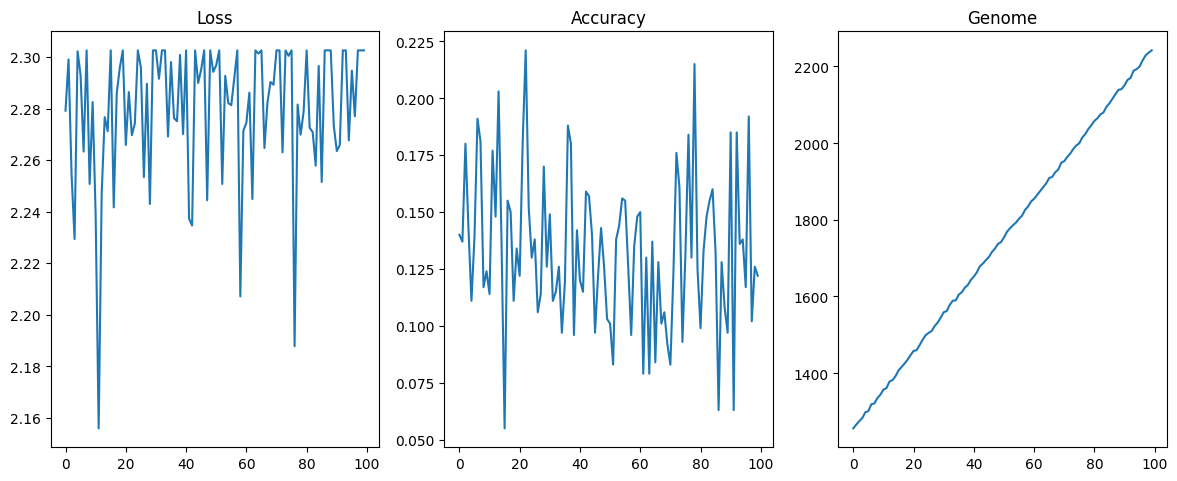

In [186]:
neat_losses =  TRAINER.run(100)

In [ ]:
MODEL.eval();

In [ ]:
POPULATION.save_dict(name='mnist', file_no=None, replace=False);

# Evaluate

In [ ]:
(1-get_accuracy(MODEL, train_inp, train_out, BATCH_SIZE, guess=True, mean=True))*100, \
(1-get_accuracy(MODEL, eval_inp, eval_out, BATCH_SIZE, guess=True, mean=True))*100

In [ ]:
(1-get_accuracy(MODEL, train_inp, train_out, BATCH_SIZE, keys=POPULATION.best_genome.key))*100, \
(1-get_accuracy(MODEL, eval_inp, eval_out, BATCH_SIZE, keys=POPULATION.best_genome.key))*100

In [ ]:
(1-get_accuracy(MODEL, train_inp, train_out, BATCH_SIZE, guess=True, keys=POPULATION.best_genome.key))*100, \
(1-get_accuracy(MODEL, eval_inp, eval_out, BATCH_SIZE, guess=True, keys=POPULATION.best_genome.key))*100

In [ ]:
def get_indices(images: Tensor, labels: Tensor, include: Union[int, list[int]] = None,
                faulty: int = False, correct: int = False, shuffle=True,
                keys: Union[int, list[int]] = None):
    if isinstance(include, (int, float)):
        include = [include]
    if keys and not isinstance(keys, (tuple, list)):
        keys = [keys]
    error_indices = []
    mapping = POPULATION.get_mapping(consolidated=True)
    indices = list(range(len(images))) if not keys else [mapping[key] for key in keys]
    images, labels = images[indices], labels[indices]
    if faulty:
        if isinstance(faulty, bool):
            faulty = 16
        with torch.no_grad():
            for batch in get_batches(labels.shape[1], faulty, False):
                pred = MODEL.evaluate(images[:, batch].to(MODEL.device), keys=keys) # shape(genomes, batch_size)
                # print(pred.shape)
                for index, errored in zip(batch, (pred!=labels[:, batch].to(MODEL.device)).mT):
                    # print(errored[:10])
                    if torch.any(errored):
                        error_indices.append(index)
        print(f"Found {len(error_indices)} record predictions with errors")
    valid_indices = []
    if correct:
        if isinstance(correct, bool):
            correct = 64
        with torch.no_grad():
            for batch in get_batches(labels.shape[1], correct, False):
                pred = MODEL.evaluate(images[:, batch].to(MODEL.device), keys=keys)
                for index, correct in zip(batch, (pred==labels[:, batch].to(MODEL.device)).mT):
                    if torch.any(correct):
                        valid_indices.append(index)
        print(f"Found {len(valid_indices)} valid record predictions ")
    indices_filtered = []
    for g_labels in labels.cpu():
        for x, record in enumerate(g_labels.cpu().tolist()):
            record_needed = include is None or record in include
            spec_type = x in error_indices or x in valid_indices
            no_type = not correct and not faulty
            if record_needed and (spec_type or no_type):
                indices_filtered.append(x)
    indices_filtered = list(set(indices_filtered))
    if shuffle:
        random.shuffle(indices_filtered)
    if len(indices_filtered) > 0:
        return indices_filtered
    else:
        raise ValueError(f"No indices available")

In [ ]:
test_records = 24
MODEL.eval();

In [ ]:
train_indices = get_indices(train_inp, train_out, faulty=BATCH_SIZE, keys=POPULATION.best_genome.key)
len(train_indices)

In [ ]:
with torch.no_grad():
    random.shuffle(train_indices)
    test_indices = train_indices[:test_records]
    test_labels = MODEL.guess(train_inp[0, test_indices].unsqueeze(0).to(DEVICE), keys=POPULATION.best_genome.key)
show_batch(train_inp[0, test_indices], test_labels[0], train_out[0, test_indices], cmap='brg_r')

In [ ]:
eval_indices = get_indices(eval_inp, eval_out, faulty=BATCH_SIZE, correct=False, keys=POPULATION.best_genome.key)
len(eval_indices)

In [ ]:
with torch.no_grad():
    random.shuffle(eval_indices)
    test_indices = eval_indices[:test_records]
    test_labels = MODEL.evaluate(eval_inp[0, test_indices].unsqueeze(0).to(DEVICE), keys=POPULATION.best_genome.key)
show_batch(eval_inp[0, test_indices], test_labels[0], eval_out[0, test_indices], cmap='brg', size=(480, 1080))

In [ ]:
with torch.no_grad():
    # random.shuffle(eval_indices)
    test_indices = eval_indices[:test_records]
    test_labels = MODEL.guess(eval_inp[0, test_indices].unsqueeze(0).to(DEVICE), keys=POPULATION.best_genome.key)
show_batch(eval_inp[0, test_indices], test_labels[0], eval_out[0, test_indices], cmap='brg', size=(480, 1080))

# PyTorch training

In [ ]:
def train2(epochs: int, batch_size: int, key: int, show=True, checkpoints=5):
    torch.cuda.empty_cache()
    MODEL.requires_grad_(True)
    # attention.causal_mask = False
    optimizer = torch.optim.AdamW(MODEL.parameters(), 1e-3)

    losses = []
    acc_train, acc_eval = [], []
    ts, ud, ut = clock.perf_counter(), 0, epochs

    # ------------------------------ Training Data ------------------------------ #
    index = POPULATION.get_mapping()[key]
    inputs, outputs = train_inp[index].unsqueeze(0).to(MODEL.device), train_out[index].unsqueeze(0).to(MODEL.device)
    print(inputs.shape, outputs.shape)

    best_loss = torch.inf
    best_epoch = -1
    save_state = MODEL.state_dict()
    batches = get_batches(inputs.shape[1], batch_size, True)
    for epoch in range(epochs):
        try:
            loss: Tensor = 0
            for batch in batches:
                # if epoch == 0:
                #     print(inputs.shape, outputs.shape)
                inp = inputs[:, batch].to(MODEL.device)
                out = outputs[0, batch].to(MODEL.device)
                predictions = MODEL(inp, keys=key).squeeze(0)
                # if epoch == 0:
                #     print(inp.shape, predictions.shape, out.shape)
                batch_loss = F.cross_entropy(predictions, out)
                batch_loss.backward()
                optimizer.step()
                optimizer.zero_grad()
                loss += batch_loss
            loss /= len(batches)

            losses.append(loss.cpu().item())
            acc_train.append(get_accuracy(MODEL, train_inp, train_out, batch_size, True, keys=key))
            acc_eval.append(get_accuracy(MODEL, eval_inp, eval_out, batch_size, True, keys=key))

            if epoch % checkpoints == 0 and loss < best_loss:
                best_loss = loss
                save_state = MODEL.state_dict()
                best_epoch = epoch

            ud += 1
            eta(ts, ud, ut, f"training | loss={loss.cpu().item():.4e} | "
                            f"best={best_loss.cpu().item():.4e} | "
                            f"epoch={best_epoch}")
        except KeyboardInterrupt:
            break
    print(f"\nFinished training in {clock.perf_counter() - ts:.2f}s")

    MODEL.load_state_dict(save_state)

    # attention.causal_mask = True
    if show:
        plt.close()
        axes = plt.subplots(1, 2, figsize=(10.8, 5.4))[1]
        axes = axes.flatten()
        axes[0].plot(np.log10(losses))
        axes[0].set_title('Loss')
        axes[1].plot(acc_train, label='train')
        axes[1].plot(acc_eval, label='eval')
        axes[1].legend()
        axes[1].set_title('Accuracy')

    MODEL.requires_grad_(False)
    torch.cuda.empty_cache()
    return losses

In [ ]:
train_losses = train2(100, BATCH_SIZE*8, POPULATION.best_genome.key, checkpoints=1)

In [ ]:
list(POPULATION.genomes.keys())[:15], POPULATION.best_genome

In [ ]:
extra_key = list(POPULATION.genomes.keys())[1]
extra_key

In [ ]:
train2(200, BATCH_SIZE*8, extra_key, checkpoints=1);

In [ ]:
extra_key2 = list(POPULATION.genomes.keys())[3]
extra_key2

In [ ]:
train2(200, BATCH_SIZE*8, extra_key2, checkpoints=1);

In [ ]:
keys_to_check = [*[g.key for g in POPULATION.best_genomes.values()], extra_key, extra_key2]
keys_to_check

In [ ]:
(1 - get_accuracy(MODEL, train_inp, train_out, 128, keys=POPULATION.best_genome.key)) * 100, \
(1 - get_accuracy(MODEL, eval_inp, eval_out, 128, keys=POPULATION.best_genome.key)) * 100

In [ ]:
(1 - get_accuracy(MODEL, train_inp, train_out, 128, guess=True, keys=POPULATION.best_genome.key)) * 100, \
(1 - get_accuracy(MODEL, eval_inp, eval_out, 128, guess=True, keys=POPULATION.best_genome.key)) * 100

In [ ]:
train_indices = get_indices(train_inp, train_out, faulty=None, keys=POPULATION.best_genome.key)

In [ ]:
with torch.no_grad():
    random.shuffle(train_indices)
    test_indices = train_indices[:test_records]
    test_labels = MODEL.guess(train_inp[0, test_indices].unsqueeze(0).to(DEVICE), keys=POPULATION.best_genome.key)
show_batch(train_inp[0, test_indices], test_labels[0], train_out[0, test_indices], cmap='brg_r')

In [ ]:
eval_indices = get_indices(eval_inp, eval_out, faulty=BATCH_SIZE*8, correct=False)
len(eval_indices)

In [ ]:
with torch.no_grad():
    random.shuffle(eval_indices)
    test_indices = eval_indices[:test_records]
    test_labels = MODEL.evaluate(eval_inp[0, test_indices].unsqueeze(0).to(DEVICE), keys=POPULATION.best_genome.key)
show_batch(eval_inp[0, test_indices], test_labels[0], eval_out[0, test_indices], cmap='brg', size=(480, 1080))

In [ ]:
with torch.no_grad():
    # random.shuffle(eval_indices)
    test_indices = eval_indices[:test_records]
    test_labels = MODEL.guess(eval_inp[0, test_indices].unsqueeze(0).to(DEVICE), keys=POPULATION.best_genome.key)
show_batch(eval_inp[0, test_indices], test_labels[0], eval_out[0, test_indices], cmap='brg', size=(480, 1080))